# Project 5: Expectation Maximization
Sophia Klymchuk and Devin Zhang

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

Generate 1D data from mixture of 3 Gaussians

In [2]:
def generate_1d_data(n=1000):
    true_means = [-3, 0, 4]
    true_vars = [0.5, 1.0, 0.8]
    true_pi = [0.3, 0.4, 0.3]   # Mixing Coefficients

    k = np.random.choice(3, size=n, p=true_pi)
    data = np.array([np.random.normal(true_means[i], np.sqrt(true_vars[i])) for i in k])
    return data

EM algorithm for 1D Gaussian Mixture Model

In [3]:
def em_1d(X, K=3, max_iter=50):
    N = len(X)

    # Initialize parameters
    mu = np.random.choice(X, K, replace=False)
    var = np.ones(K)
    pi = np.ones(K) / K

    history = [(mu.copy(), var.copy(), pi.copy())]

    for iteration in range(max_iter):
        gamma = np.zeros((N, K))
        for k in range(K):  # Each point has K responsibilities
            # E-step (Expectation): compute responsibilities gamma (eq 9.23)
            gamma[:, k] = pi[k] * norm.pdf(X, mu[k], np.sqrt(var[k]))   # If X is close to mu[k], norm.pdf[~] grows.
            # Each point gets a probability distribution over all K Gaussians

        gamma /= gamma.sum(axis=1, keepdims=True)  # Normalize responsibilities for every row/point.

        for k in range(K):
            # M-step (Maximization): update parameters for each k
            N_k = gamma[:, k].sum()   # eq 9.24. How much total weight k gets from ALL data points. (Effectively # of points)
            mu[k] = (gamma[:, k] @ X) / N_k  # eq 9.25. Weighted average of ALL points (weighted by gamma_nk)
            var[k] = (gamma[:, k] @ (X - mu[k])**2) / N_k  # eq 9.26. Weighted variance of ALL points
            pi[k] = N_k / len(X)  # eq 9.27. Proportion of "total responsibility" k received

        history.append((mu.copy(), var.copy(), pi.copy()))

    return mu, var, pi, history

Old Faithful dataset

In [4]:
def load_old_faithful():
    df = sns.load_dataset('geyser')
    return df[['duration', 'waiting']].values

EM algorithm for 2D Gaussian Mixture Model

In [5]:
def em_2d(X, K=2, max_iter=50):
    N, D = X.shape

    # Initialize parameters
    idx = np.random.choice(N, K, replace=False)
    mu = X[idx]
    cov = [np.eye(D) for _ in range(K)]
    pi = np.ones(K) / K

    for iteration in range(max_iter):
        gamma = np.zeros((N, K))

        for k in range(K):  # Each point has K responsibilities
            # E-step (Expectation): compute responsibilities gamma
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X, mu[k], cov[k])  # If X is close to mu[k], pdf grows
            # Each point gets a probability distribution over all K Gaussians

        gamma /= gamma.sum(axis=1, keepdims=True)  # Normalize responsibilities for every row/point

        for k in range(K):
            # M-step (Maximization): update parameters for each k
            N_k = gamma[:, k].sum()  # How much total weight k gets from ALL data points. (Effectively # of points)

            mu[k] = (gamma[:, k] @ X) / N_k  # Weighted average of ALL points (weighted by gamma_nk) - D-dimensional vector

            diff = X - mu[k]  # Deviation of each point from cluster k's mean (N x D matrix)
            cov[k] = (gamma[:, k][:, np.newaxis] * diff).T @ diff / N_k  # Weighted covariance of ALL points (D x D matrix)

            pi[k] = N_k / N  # Proportion of "total responsibility" k received

    return mu, cov, pi, gamma

Plot 2D GMM with clusters and contours

In [6]:
def plot_2d_gmm(X, mu, cov, gamma):
    plt.figure()

    # Assign points to clusters
    labels = gamma.argmax(axis=1)

    # Plot points colored by cluster
    colors = ['red', 'blue']
    for k in range(len(mu)):
        mask = labels == k
        plt.scatter(X[mask, 0], X[mask, 1], c=colors[k])

    # Create grid for contour plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Plot contours for each cluster
    for k in range(len(mu)):
        Z = multivariate_normal.pdf(np.c_[xx.ravel(), yy.ravel()], mu[k], cov[k])
        Z = Z.reshape(xx.shape)
        plt.contour(xx, yy, Z, colors=colors[k])

    plt.xlabel('Eruption time (min)')
    plt.ylabel('Waiting time (min)')
    plt.title('Old Faithful Dataset - GMM with K=2')
    plt.show()

Animate convergence of EM algorithm

In [7]:
def make_movie(X, history):
    fig, ax = plt.subplots()
    x_range = np.linspace(X.min(), X.max(), 1000)

    def animate(i):
        ax.clear()

        # Plot histogram of data
        ax.hist(X, bins=50, density=True)

        # Get parameters at iteration i
        mu, var, pi = history[i]
        pdf = np.zeros_like(x_range)

        # Plot each component and compute total pdf
        for k in range(len(mu)):
            component = pi[k] * norm.pdf(x_range, mu[k], np.sqrt(var[k]))
            pdf += component
            ax.plot(x_range, component, '--')

        # Plot total mixture pdf
        ax.plot(x_range, pdf, 'r', linewidth=2)
        ax.set_xlabel('x')
        ax.set_ylabel('Density')
        ax.set_title(f'Iteration {i}')

    anim = FuncAnimation(fig, animate, frames=len(history), interval=30, repeat=True)
    return HTML(anim.to_jshtml())

Execution

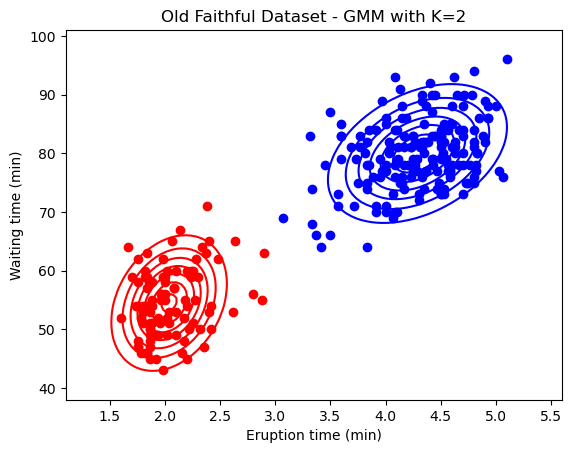

In [8]:
np.random.seed(42)

# 1D GMM
X_1d = generate_1d_data()
mu, var, pi, history = em_1d(X_1d, K=3)
anim_html = make_movie(X_1d, history)
display(anim_html)
plt.close('all')

# 2D GMM
X_2d = load_old_faithful()
mu_2d, cov_2d, pi_2d, gamma = em_2d(X_2d, K=2)
plot_2d_gmm(X_2d, mu_2d, cov_2d, gamma)